In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap

from sklearn.base import clone
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from attrition_analysis.models_utils import (
    estimators_dict,
    mixed_models_dict_c,
    categorical_models_dict_c,
    prepare_model_data,
    run_cross_validation_mixed,
    run_model_comparison_mixed,
)


df = pd.read_csv("../../data/clean/Employee-Attrition_Clean.csv")

target = "AttritionFlag"

logistic_estimators_dict = {
    "Logistic Regression": estimators_dict["Logistic Regression"],
    "Logistic Regression Balanced": estimators_dict["Logistic Regression Balanced"]
}

In [2]:
all_models_dict_c = {**categorical_models_dict_c, **mixed_models_dict_c}

In [3]:
general_comparison_lr, threshold_comparison_lr, confusion_results_lr, trained_models_lr, interpretation_results_lr = run_model_comparison_mixed(
    df=df,
    models_dict=all_models_dict_c,
    estimators_dict=logistic_estimators_dict,
    target=target
)


general_comparison_lr.sort_values(by=["F1-score", "AUC"], ascending=False)

,Variable_Set,Model,Threshold,Accuracy,Precision,Recall,F1-score,AUC,N_Numeric_Variables,N_Categorical_Variables,N_Features_After_Dummies
17,Modelo 2 — Nível Hierárquico e Benefícios,Logistic Regression Balanced,0.5,0.769,0.388,0.761,0.514,0.829,3,8,25
3,Modelo 2 — Nível Hierárquico,Logistic Regression Balanced,0.5,0.776,0.394,0.732,0.512,0.815,0,8,22
19,Modelo 3 — Rendimento Quantitativo,Logistic Regression Balanced,0.5,0.760,0.378,0.761,0.505,0.792,4,6,19
28,Modelo 8 — Integrado Multidimensional,Logistic Regression,0.5,0.868,0.644,0.408,0.500,0.808,7,11,43
23,Modelo 5 — Antiguidade Organizacional,Logistic Regression Balanced,0.5,0.764,0.378,0.718,0.495,0.777,5,6,20
21,Modelo 4 — Experiência Profissional,Logistic Regression Balanced,0.5,0.766,0.379,0.704,0.493,0.792,4,6,19
29,Modelo 8 — Integrado Multidimensional,Logistic Regression Balanced,0.5,0.766,0.377,0.690,0.488,0.810,7,11,43
25,Modelo 6 — Perfil Pessoal e Condições de Trabalho,Logistic Regression Balanced,0.5,0.748,0.355,0.690,0.469,0.802,3,8,24
11,Modelo 6 — Perfil Pessoal,Logistic Regression Balanced,0.5,0.753,0.358,0.676,0.468,0.801,0,9,24
5,Modelo 3 — Faixa Salarial,Logistic Regression Balanced,0.5,0.737,0.345,0.704,0.463,0.790,0,8,21


In [4]:
best_thresholds_lr = threshold_comparison_lr.loc[
    threshold_comparison_lr.groupby(["Variable_Set", "Model"])["F1-score"].idxmax()
].reset_index(drop=True)

best_thresholds_lr.sort_values(by="F1-score", ascending=False)

,Variable_Set,Model,Threshold,Accuracy,Precision,Recall,F1-score,AUC
28,Modelo 8 — Integrado Multidimensional,Logistic Regression,0.325,0.859,0.557,0.620,0.587,0.808
29,Modelo 8 — Integrado Multidimensional,Logistic Regression Balanced,0.650,0.844,0.511,0.634,0.566,0.810
6,Modelo 2 — Nível Hierárquico e Benefícios,Logistic Regression,0.275,0.846,0.518,0.606,0.558,0.827
7,Modelo 2 — Nível Hierárquico e Benefícios,Logistic Regression Balanced,0.650,0.834,0.489,0.606,0.541,0.829
9,Modelo 3 — Faixa Salarial,Logistic Regression Balanced,0.625,0.834,0.489,0.606,0.541,0.790
5,Modelo 2 — Nível Hierárquico,Logistic Regression Balanced,0.575,0.814,0.449,0.676,0.539,0.815
19,Modelo 5 — Estabilidade e Benefícios,Logistic Regression Balanced,0.650,0.846,0.521,0.535,0.528,0.793
8,Modelo 3 — Faixa Salarial,Logistic Regression,0.275,0.832,0.482,0.577,0.526,0.784
4,Modelo 2 — Nível Hierárquico,Logistic Regression,0.225,0.814,0.446,0.634,0.523,0.811
11,Modelo 3 — Rendimento Quantitativo,Logistic Regression Balanced,0.550,0.789,0.411,0.718,0.523,0.792


In [5]:
top_5_best_lr = best_thresholds_lr.sort_values(by="F1-score", ascending=False).head(5).reset_index(drop=True)

top_5_best_lr

,Variable_Set,Model,Threshold,Accuracy,Precision,Recall,F1-score,AUC
0,Modelo 8 — Integrado Multidimensional,Logistic Regression,0.325,0.859,0.557,0.620,0.587,0.808
1,Modelo 8 — Integrado Multidimensional,Logistic Regression Balanced,0.650,0.844,0.511,0.634,0.566,0.810
2,Modelo 2 — Nível Hierárquico e Benefícios,Logistic Regression,0.275,0.846,0.518,0.606,0.558,0.827
3,Modelo 2 — Nível Hierárquico e Benefícios,Logistic Regression Balanced,0.650,0.834,0.489,0.606,0.541,0.829
4,Modelo 3 — Faixa Salarial,Logistic Regression Balanced,0.625,0.834,0.489,0.606,0.541,0.790


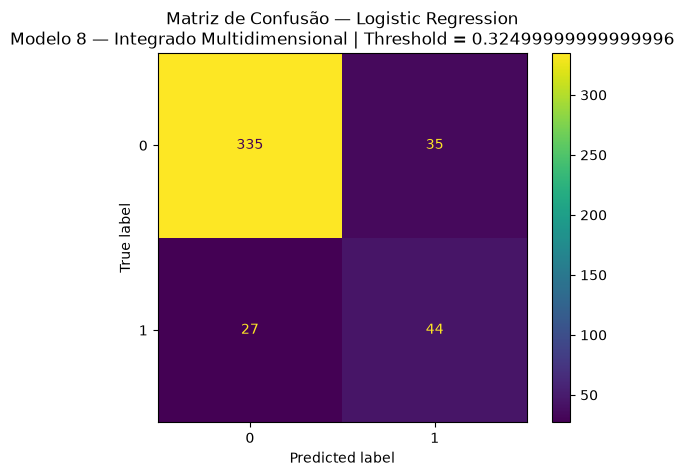

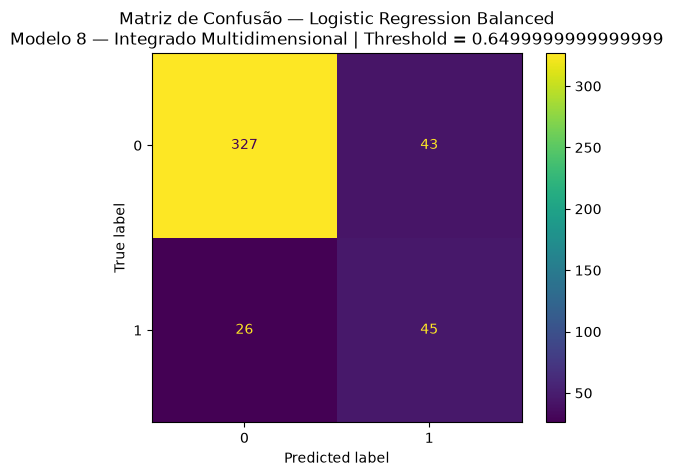

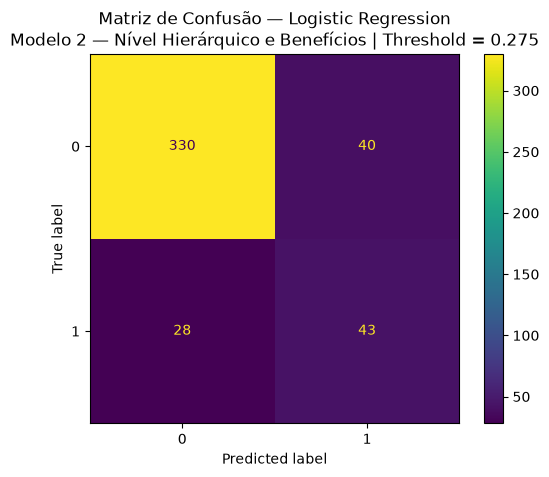

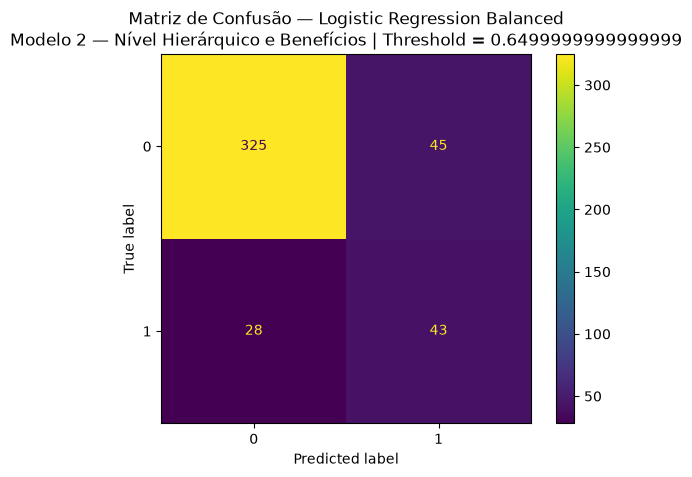

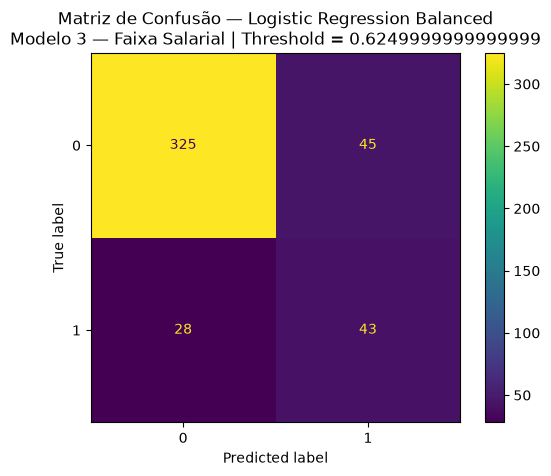

In [6]:
for _, row in top_5_best_lr.iterrows():
    
    variable_set_name = row["Variable_Set"]
    model_name = row["Model"]
    best_threshold = row["Threshold"]
    
    model_info = all_models_dict_c[variable_set_name]
    numeric_vars = model_info["numeric_vars"]
    categorical_vars = model_info["categorical_vars"]
    
    X, y = prepare_model_data(
        df=df,
        numeric_vars=numeric_vars,
        categorical_vars=categorical_vars,
        target=target
    )
    
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.30,
        random_state=42,
        stratify=y
    )
    
    X_train_model = X_train.copy()
    X_test_model = X_test.copy()
    
    if len(numeric_vars) > 0:
        
        numeric_cols_existing = [
            col for col in numeric_vars
            if col in X_train_model.columns
        ]
        
        scaler = StandardScaler()
        
        X_train_model[numeric_cols_existing] = scaler.fit_transform(
            X_train_model[numeric_cols_existing]
        )
        
        X_test_model[numeric_cols_existing] = scaler.transform(
            X_test_model[numeric_cols_existing]
        )
    
    estimator = clone(logistic_estimators_dict[model_name]["estimator"])
    
    estimator.fit(X_train_model, y_train)
    
    y_prob = estimator.predict_proba(X_test_model)[:, 1]
    y_pred = (y_prob >= best_threshold).astype(int)
    
    cm = confusion_matrix(y_test, y_pred)
    
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(f"Matriz de Confusão — {model_name}\n{variable_set_name} | Threshold = {best_threshold}")
    plt.show()

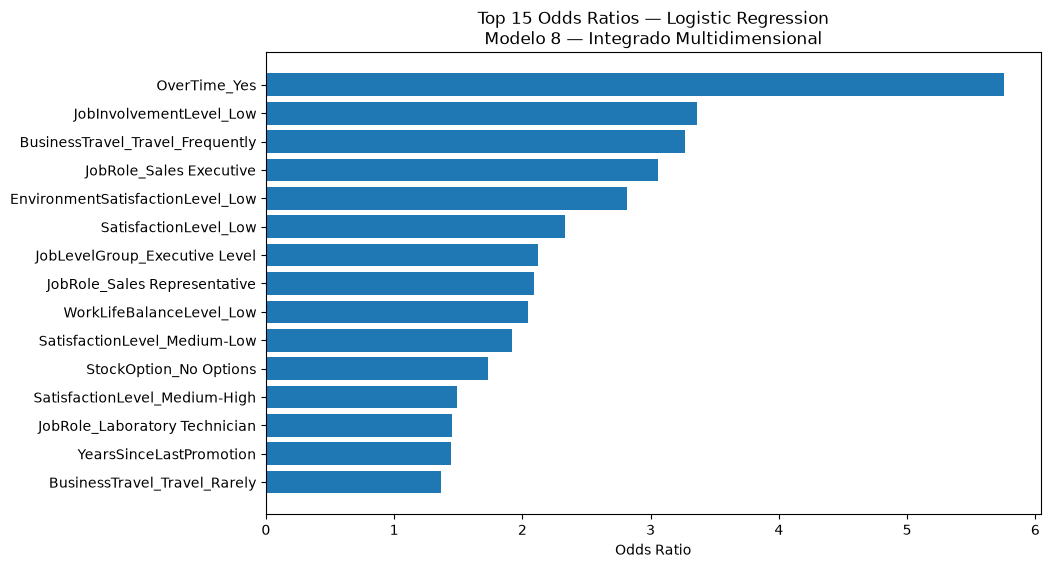

,Feature,Coefficient,Odds_Ratio
7,OverTime_Yes,1.750159,5.755517
31,JobInvolvementLevel_Low,1.212982,3.363499
29,BusinessTravel_Travel_Frequently,1.184047,3.267572
14,JobRole_Sales Executive,1.117021,3.055736
34,EnvironmentSatisfactionLevel_Low,1.034053,2.812442
37,SatisfactionLevel_Low,0.845606,2.329390
16,JobLevelGroup_Executive Level,0.751011,2.119141
15,JobRole_Sales Representative,0.737876,2.091489
40,WorkLifeBalanceLevel_Low,0.714774,2.043725
39,SatisfactionLevel_Medium-Low,0.651202,1.917845


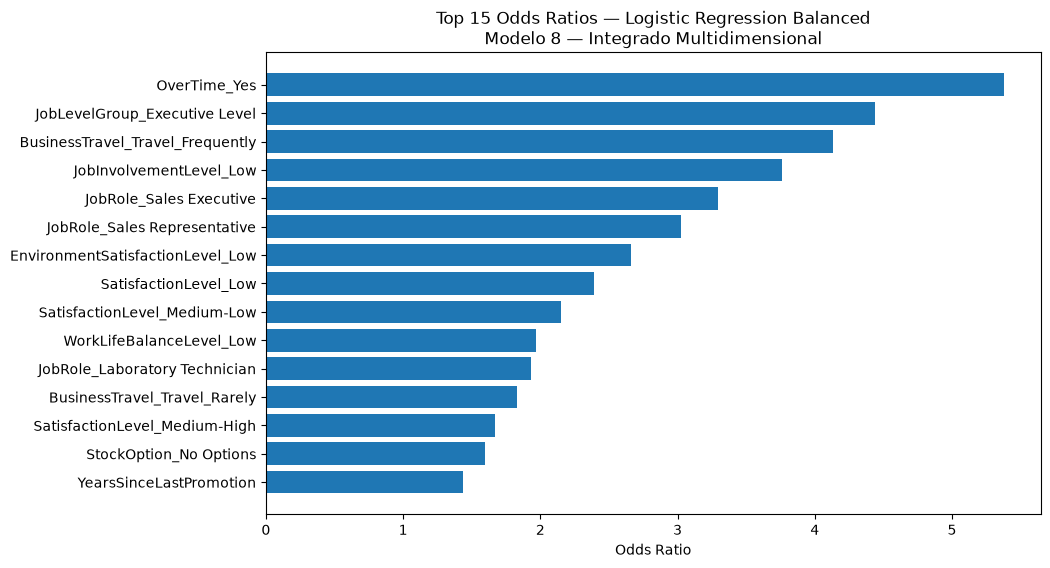

,Feature,Coefficient,Odds_Ratio
7,OverTime_Yes,1.682494,5.378955
16,JobLevelGroup_Executive Level,1.490982,4.441455
29,BusinessTravel_Travel_Frequently,1.418877,4.132477
31,JobInvolvementLevel_Low,1.324851,3.761625
14,JobRole_Sales Executive,1.191868,3.293227
15,JobRole_Sales Representative,1.106778,3.024597
34,EnvironmentSatisfactionLevel_Low,0.978203,2.659672
37,SatisfactionLevel_Low,0.871042,2.389400
39,SatisfactionLevel_Medium-Low,0.765864,2.150852
40,WorkLifeBalanceLevel_Low,0.677548,1.969043


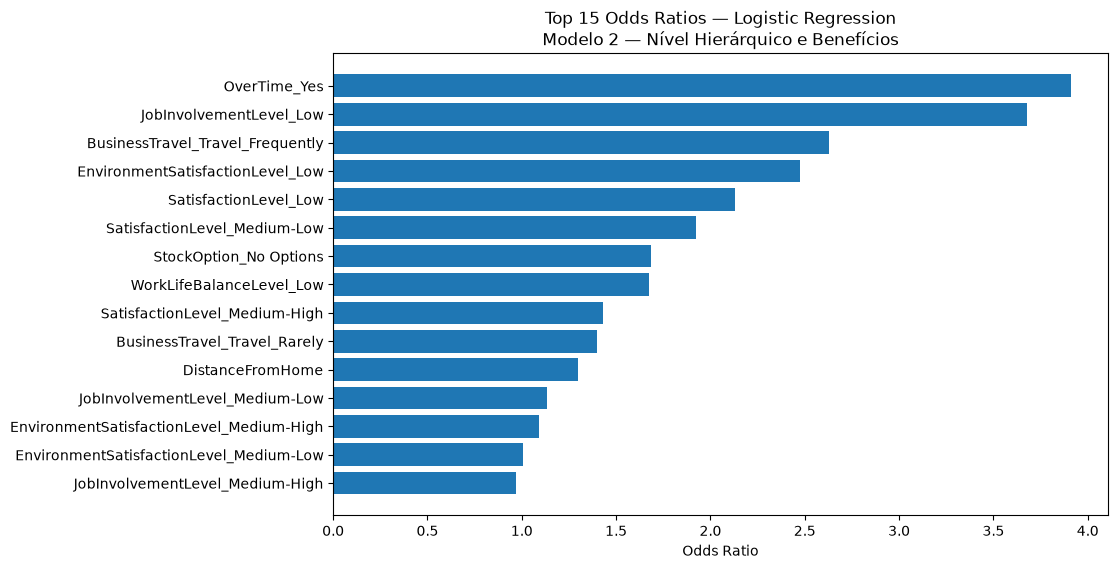

,Feature,Coefficient,Odds_Ratio
3,OverTime_Yes,1.364198,3.912586
13,JobInvolvementLevel_Low,1.302089,3.676970
11,BusinessTravel_Travel_Frequently,0.967149,2.630434
16,EnvironmentSatisfactionLevel_Low,0.907076,2.477070
19,SatisfactionLevel_Low,0.754975,2.127558
21,SatisfactionLevel_Medium-Low,0.654524,1.924227
10,StockOption_No Options,0.521426,1.684428
22,WorkLifeBalanceLevel_Low,0.515327,1.674186
20,SatisfactionLevel_Medium-High,0.359080,1.432011
12,BusinessTravel_Travel_Rarely,0.334969,1.397897


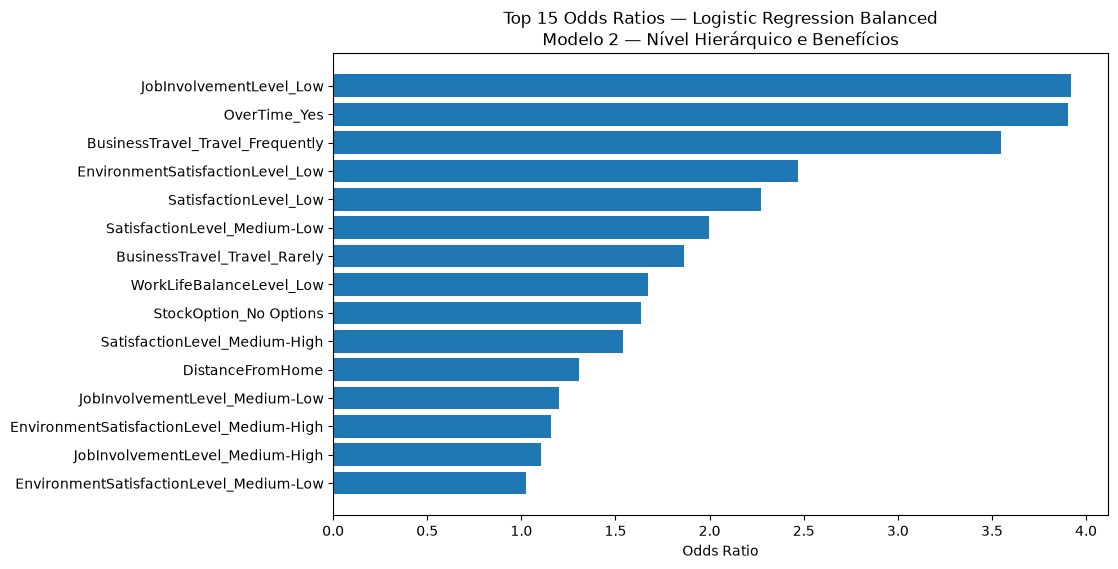

,Feature,Coefficient,Odds_Ratio
13,JobInvolvementLevel_Low,1.366440,3.921366
3,OverTime_Yes,1.361365,3.901516
11,BusinessTravel_Travel_Frequently,1.266594,3.548746
16,EnvironmentSatisfactionLevel_Low,0.903189,2.467460
19,SatisfactionLevel_Low,0.820998,2.272767
21,SatisfactionLevel_Medium-Low,0.691141,1.995992
12,BusinessTravel_Travel_Rarely,0.623039,1.864587
22,WorkLifeBalanceLevel_Low,0.515146,1.673883
10,StockOption_No Options,0.491599,1.634928
20,SatisfactionLevel_Medium-High,0.431262,1.539198


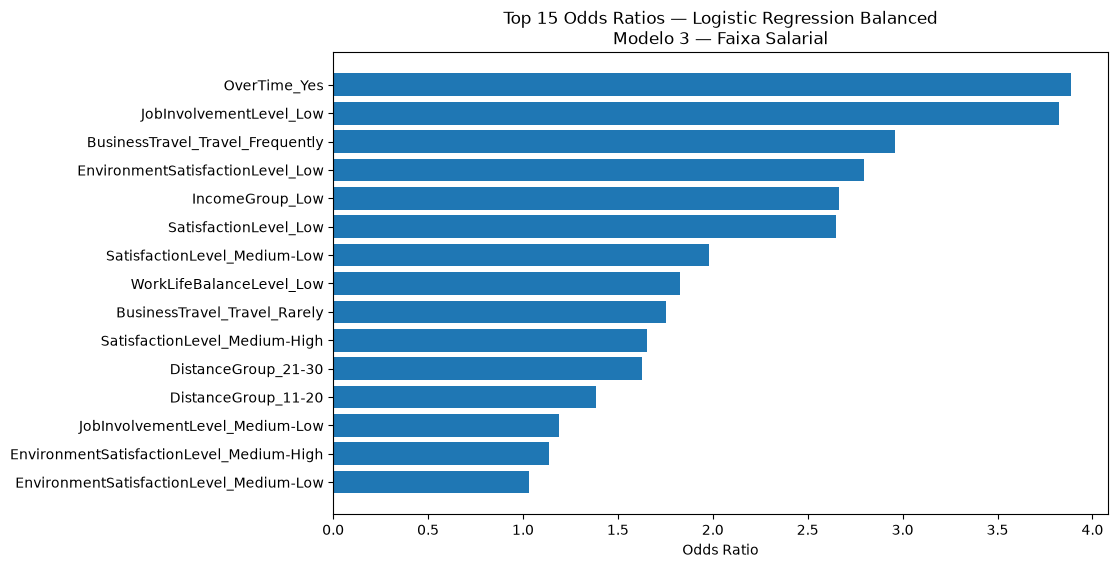

,Feature,Coefficient,Odds_Ratio
0,OverTime_Yes,1.358012,3.888454
6,JobInvolvementLevel_Low,1.340687,3.821666
4,BusinessTravel_Travel_Frequently,1.084815,2.958893
9,EnvironmentSatisfactionLevel_Low,1.028439,2.796698
1,IncomeGroup_Low,0.980784,2.666546
12,SatisfactionLevel_Low,0.975204,2.651709
14,SatisfactionLevel_Medium-Low,0.683206,1.980217
15,WorkLifeBalanceLevel_Low,0.603785,1.829028
5,BusinessTravel_Travel_Rarely,0.562724,1.755448
13,SatisfactionLevel_Medium-High,0.501921,1.651891


In [7]:
for _, row in top_5_best_lr.iterrows():
    
    variable_set_name = row["Variable_Set"]
    model_name = row["Model"]
    
    importance_df = interpretation_results_lr[variable_set_name][model_name].copy()
    
    top_importance = importance_df.head(15).sort_values(by="Odds_Ratio", ascending=True)
    
    plt.figure(figsize=(10, 6))
    plt.barh(top_importance["Feature"], top_importance["Odds_Ratio"])
    plt.xlabel("Odds Ratio")
    plt.title(f"Top 15 Odds Ratios — {model_name}\n{variable_set_name}")
    plt.show()
    
    display(importance_df.head(20))

Background dataset has 1029 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=1029 when initializing the masker.


SHAP — Logistic Regression | Modelo 8 — Integrado Multidimensional


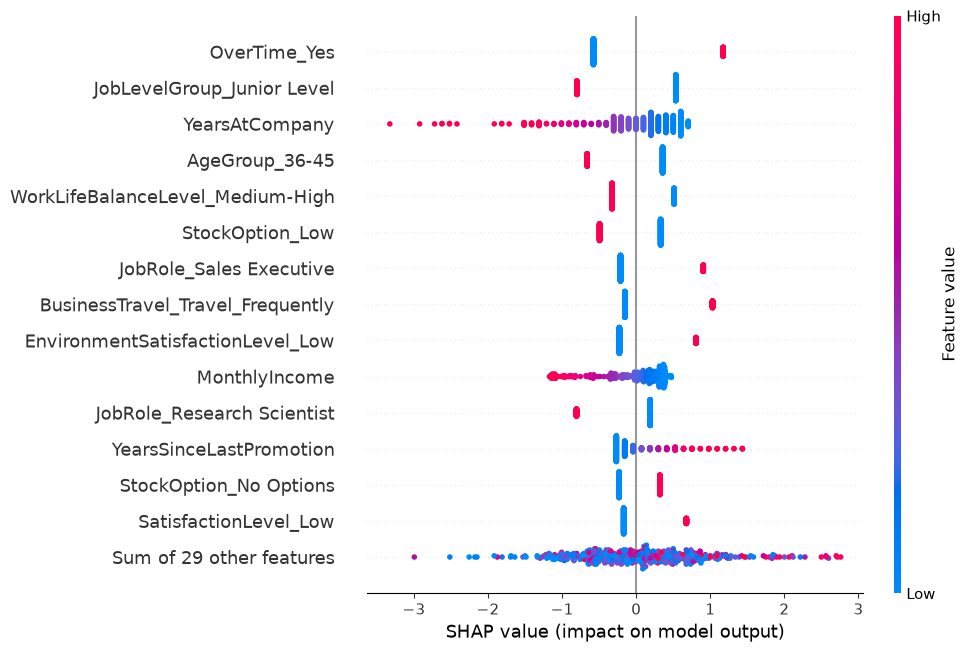

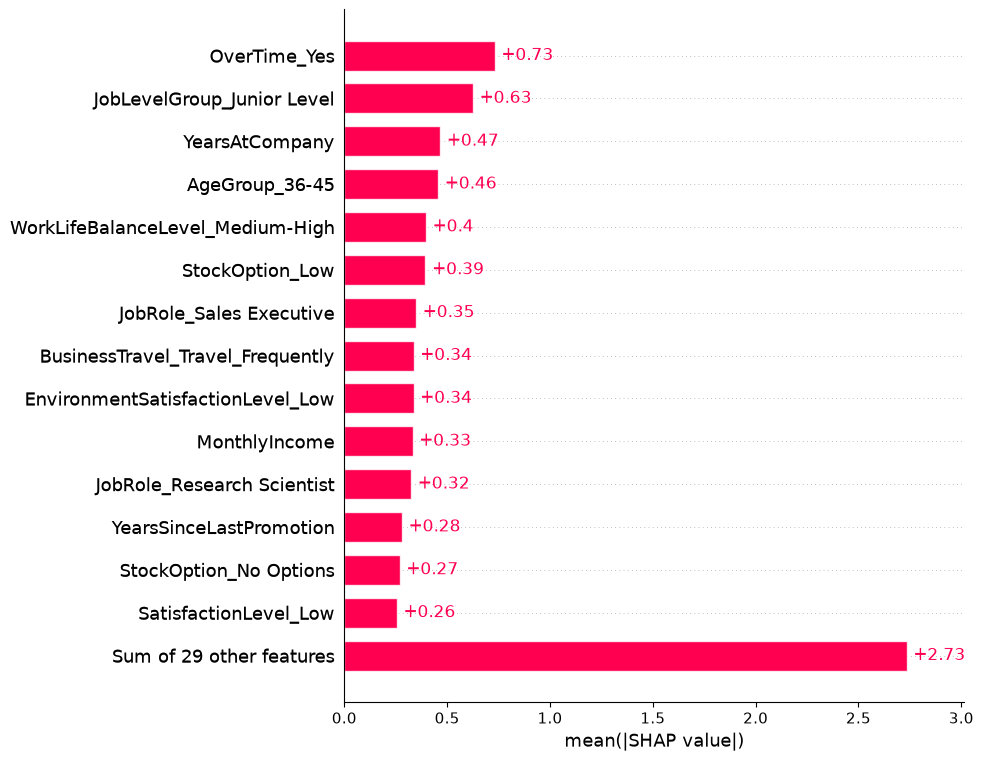

Background dataset has 1029 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=1029 when initializing the masker.


SHAP — Logistic Regression Balanced | Modelo 8 — Integrado Multidimensional


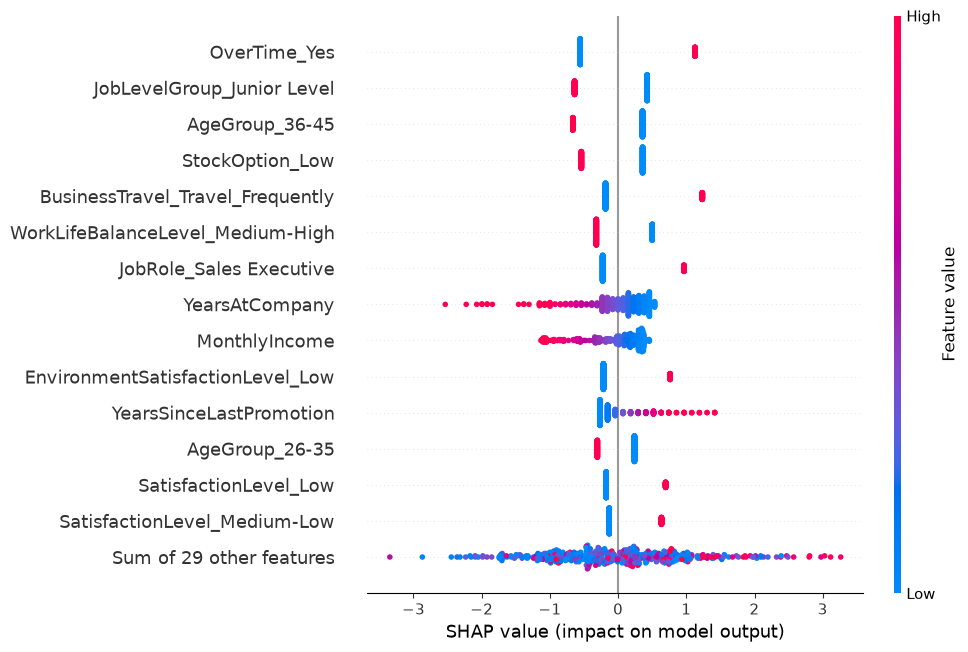

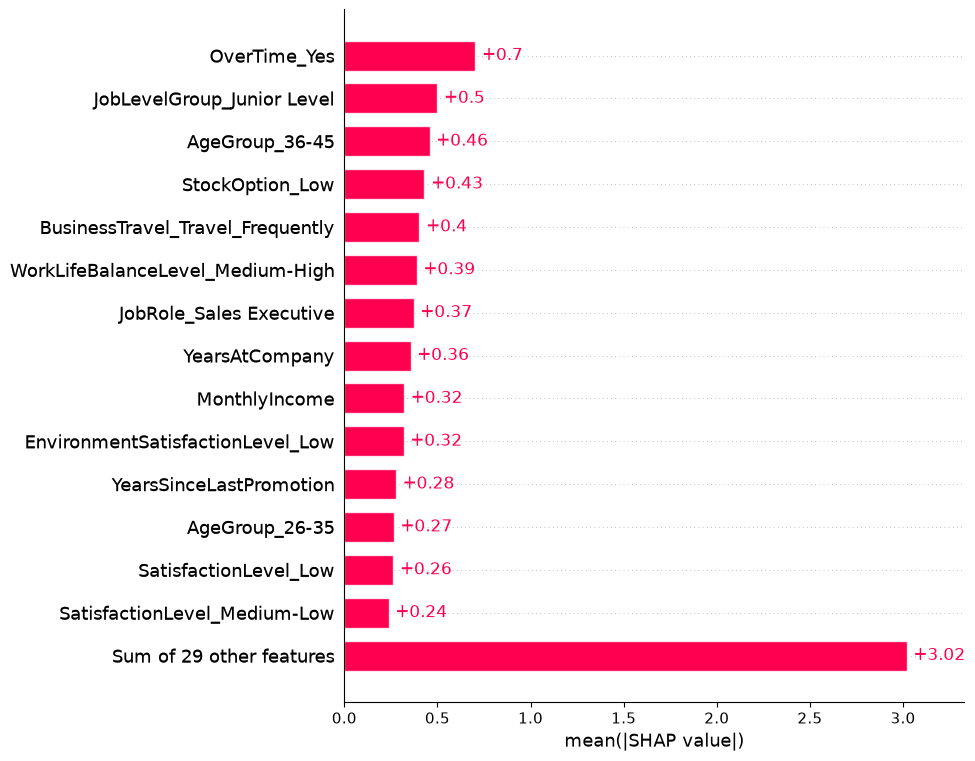

Background dataset has 1029 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=1029 when initializing the masker.


SHAP — Logistic Regression | Modelo 2 — Nível Hierárquico e Benefícios


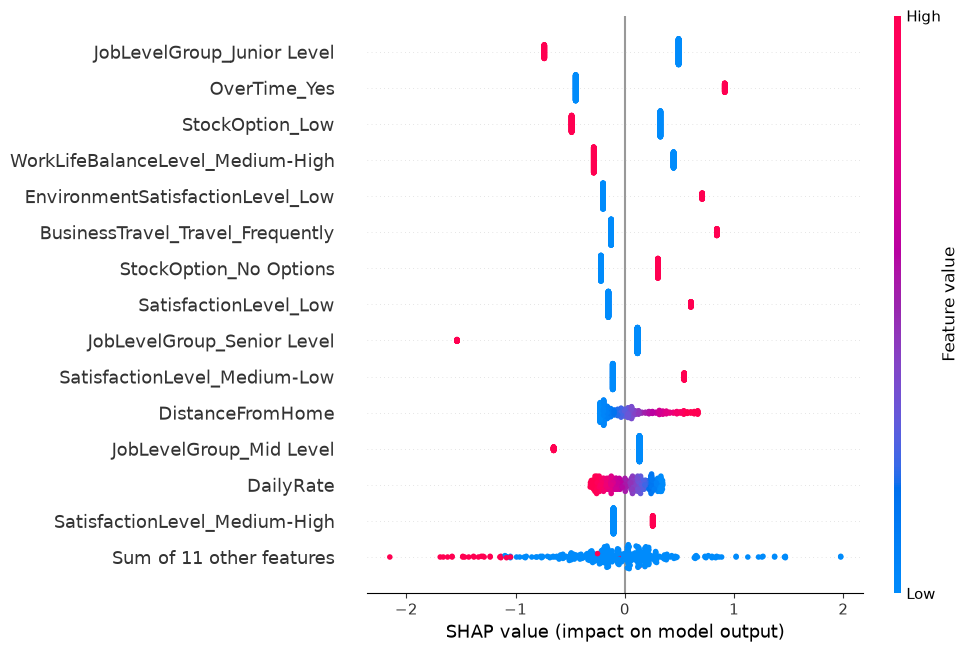

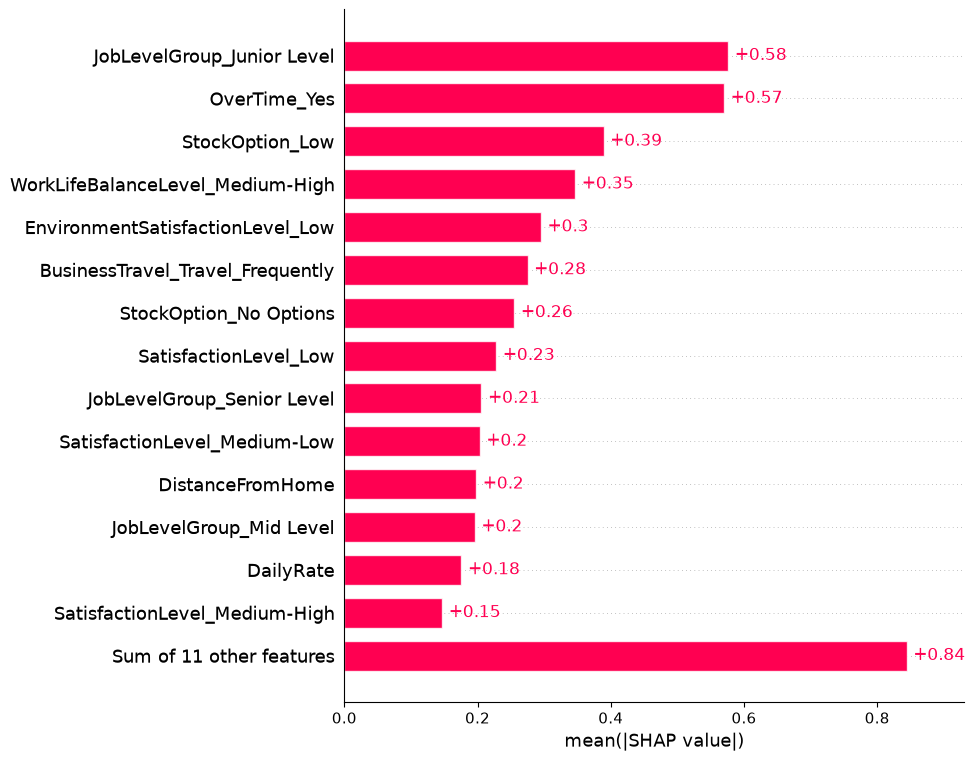

Background dataset has 1029 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=1029 when initializing the masker.


SHAP — Logistic Regression Balanced | Modelo 2 — Nível Hierárquico e Benefícios


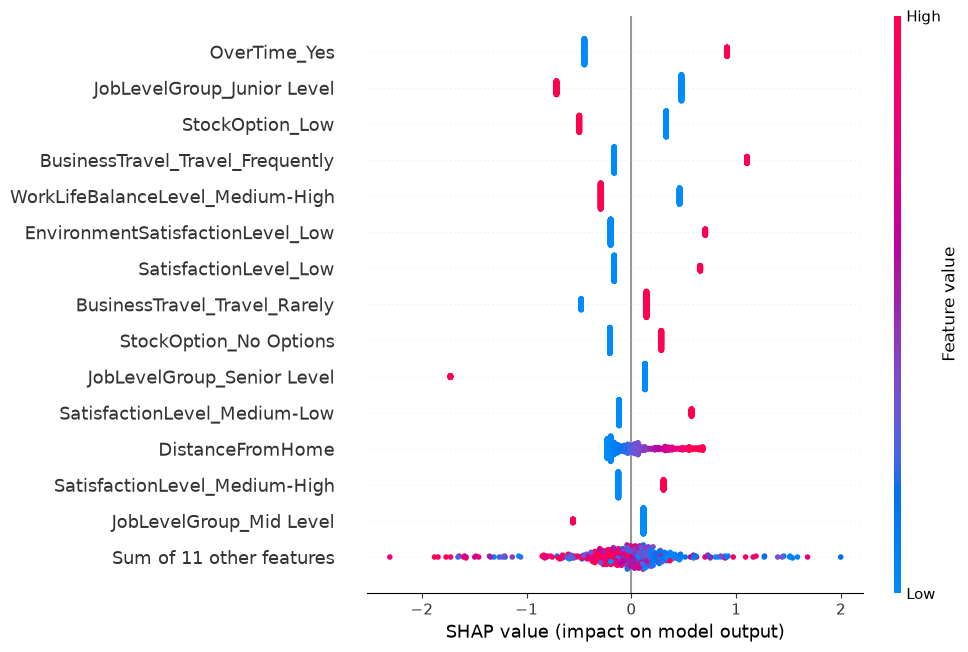

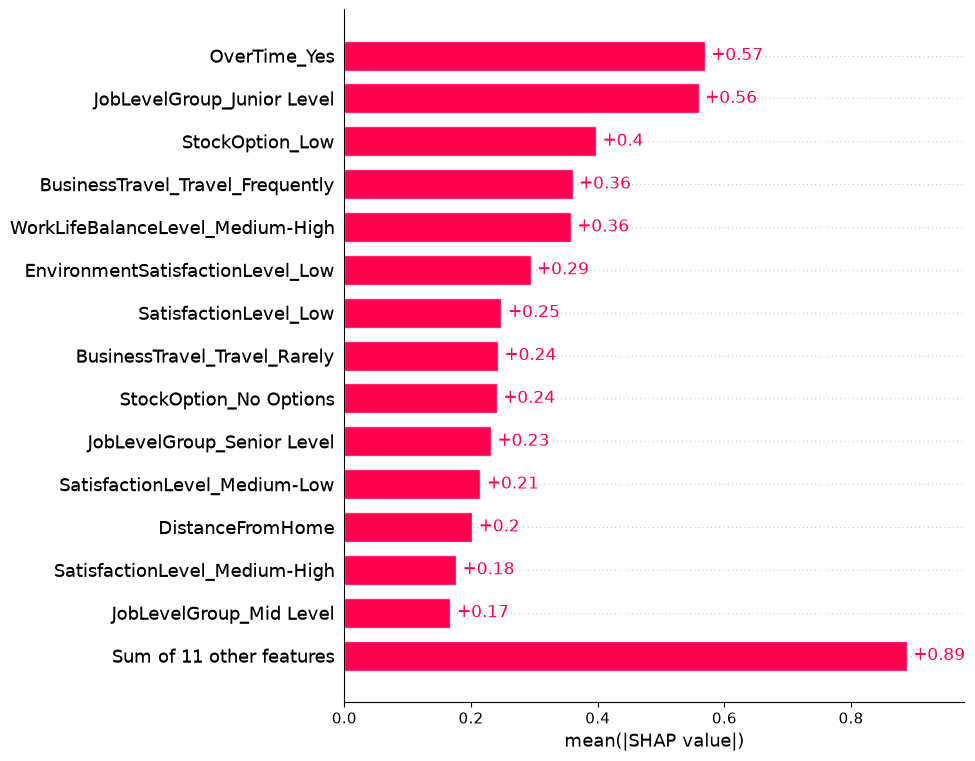

Background dataset has 1029 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=1029 when initializing the masker.


SHAP — Logistic Regression Balanced | Modelo 3 — Faixa Salarial


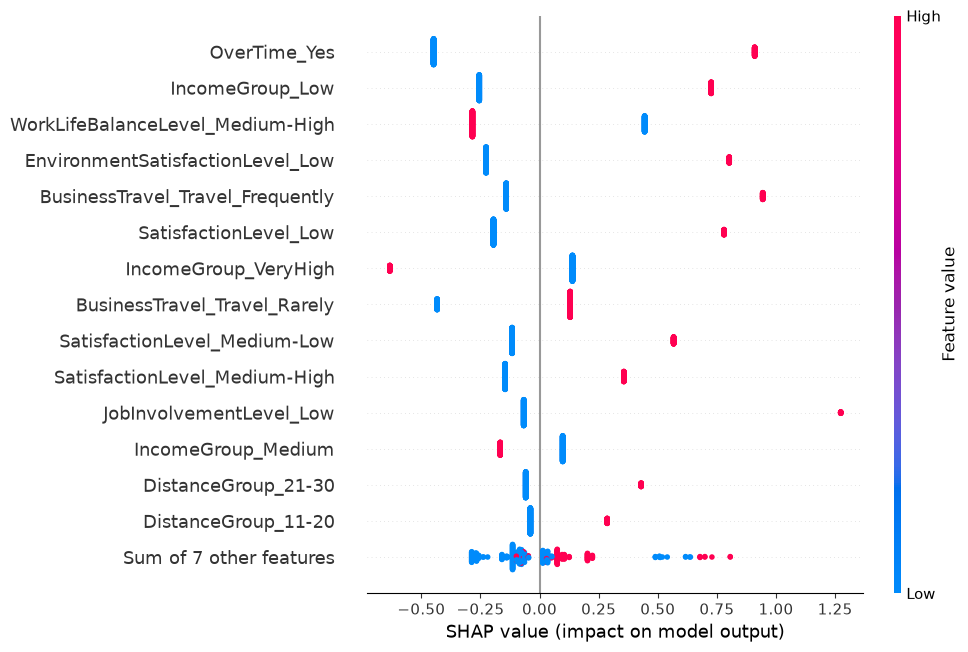

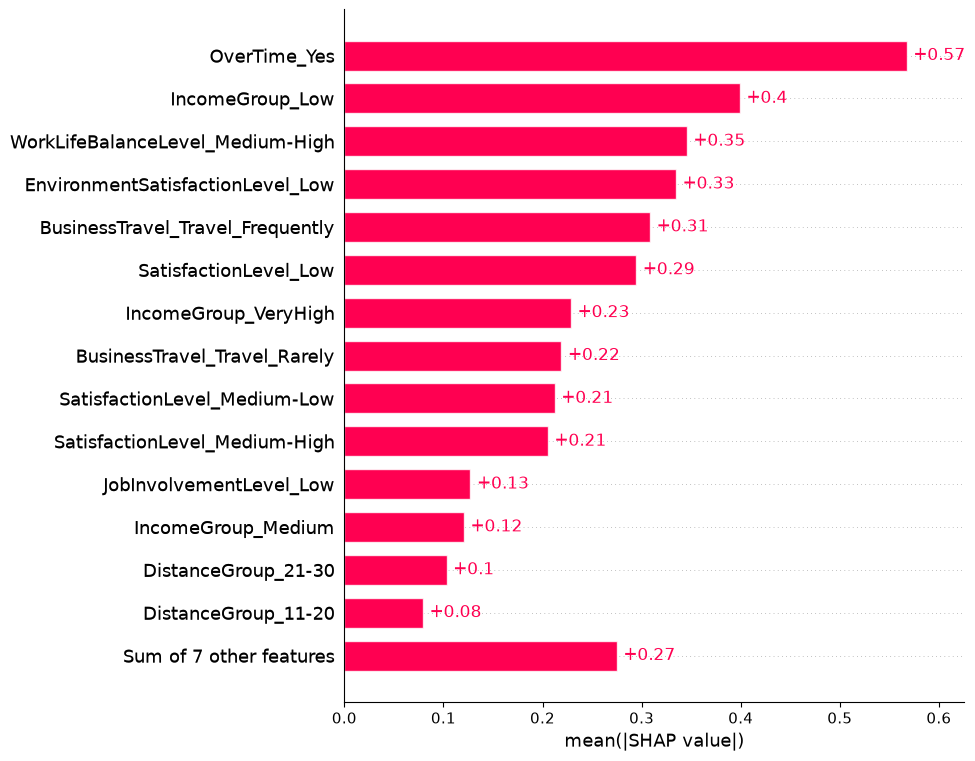

In [8]:
for _, row in top_5_best_lr.iterrows():
    
    variable_set_name = row["Variable_Set"]
    model_name = row["Model"]
    
    model_info = all_models_dict_c[variable_set_name]
    numeric_vars = model_info["numeric_vars"]
    categorical_vars = model_info["categorical_vars"]
    
    X, y = prepare_model_data(
        df=df,
        numeric_vars=numeric_vars,
        categorical_vars=categorical_vars,
        target=target
    )
    
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.30,
        random_state=42,
        stratify=y
    )
    
    X_train_model = X_train.copy()
    X_test_model = X_test.copy()
    
    if len(numeric_vars) > 0:
        
        numeric_cols_existing = [
            col for col in numeric_vars
            if col in X_train_model.columns
        ]
        
        scaler = StandardScaler()
        
        X_train_model[numeric_cols_existing] = scaler.fit_transform(
            X_train_model[numeric_cols_existing]
        )
        
        X_test_model[numeric_cols_existing] = scaler.transform(
            X_test_model[numeric_cols_existing]
        )
    
    estimator = clone(logistic_estimators_dict[model_name]["estimator"])
    estimator.fit(X_train_model, y_train)
    
    explainer = shap.LinearExplainer(estimator, X_train_model)
    shap_values = explainer(X_test_model)
    
    print(f"SHAP — {model_name} | {variable_set_name}")
    
    shap.plots.beeswarm(shap_values, max_display=15)
    shap.plots.bar(shap_values, max_display=15)

# Validação Cruzada

In [9]:
cv_logistic = run_cross_validation_mixed(
    df=df,
    models_dict=all_models_dict_c,
    estimators_dict={
        "Logistic Regression": estimators_dict["Logistic Regression"],
        "Logistic Regression Balanced": estimators_dict["Logistic Regression Balanced"]
    },
    target="AttritionFlag"
)

cv_logistic.sort_values("F1_Mean", ascending=False)

,Variable_Set,Model,Accuracy_Mean,Accuracy_Std,Precision_Mean,Precision_Std,Recall_Mean,Recall_Std,F1_Mean,F1_Std,AUC_Mean,AUC_Std,N_Numeric_Variables,N_Categorical_Variables,N_Features_After_Dummies
29,Modelo 8 — Integrado Multidimensional,Logistic Regression Balanced,0.776,0.035,0.401,0.051,0.776,0.085,0.528,0.062,0.839,0.055,7,11,43
17,Modelo 2 — Nível Hierárquico e Benefícios,Logistic Regression Balanced,0.754,0.030,0.371,0.039,0.737,0.079,0.492,0.048,0.814,0.047,3,8,25
28,Modelo 8 — Integrado Multidimensional,Logistic Regression,0.872,0.022,0.698,0.126,0.372,0.095,0.480,0.101,0.844,0.051,7,11,43
21,Modelo 4 — Experiência Profissional,Logistic Regression Balanced,0.737,0.045,0.356,0.048,0.746,0.078,0.480,0.054,0.787,0.051,4,6,19
11,Modelo 6 — Perfil Pessoal,Logistic Regression Balanced,0.736,0.033,0.351,0.036,0.730,0.040,0.473,0.038,0.793,0.048,0,9,24
25,Modelo 6 — Perfil Pessoal e Condições de Trabalho,Logistic Regression Balanced,0.737,0.030,0.349,0.037,0.722,0.064,0.470,0.044,0.799,0.050,3,8,24
9,Modelo 5 — Estabilidade e Benefícios,Logistic Regression Balanced,0.741,0.035,0.354,0.042,0.704,0.068,0.468,0.039,0.797,0.049,0,9,24
7,Modelo 4 — Trajetória Organizacional,Logistic Regression Balanced,0.733,0.053,0.348,0.071,0.708,0.083,0.465,0.076,0.790,0.047,0,8,22
3,Modelo 2 — Nível Hierárquico,Logistic Regression Balanced,0.737,0.037,0.347,0.045,0.695,0.074,0.462,0.054,0.786,0.053,0,8,22
15,Modelo 1 — Função Profissional Misto,Logistic Regression Balanced,0.731,0.021,0.341,0.027,0.712,0.073,0.460,0.039,0.800,0.057,3,7,26
